# Movie Data Visualization Project:

In [1]:
# import needed libraries:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
from dash import Dash, html, dcc, callback, Input, Output

In [2]:
# load movie dataset:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sydne\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2


In [3]:
# load dataset as dataframe:
movies_df = pd.read_csv("tmdb_5000_movies.csv")
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
# get column names:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

# Column Values and Descriptions:
- budget: int64, "cost to make the movie." (will use)
- genres: object, "genre names of movie. Messy values" (no use)
- homepage: object, "homepage url for each movie." (will not use)
- id: int64, "primary key for each movie" (will not use)
- keywords: object, "common words to describe/said in the movie. Messy values" (will not use)
- original_language: object, "original language the movie was created for" (will use)
- original_title: object, "original title the movie had before release" (will not use)
- overview: object, "about/description of the movie" (will not use)
- popularity: float64, "metric of the overall movie popularity (viewership)" (will use)
- production_companies: object, "the production companies involved with the movie. Messy values" (will not use)
- production_countries: object, "the countries involved with the production of the movie. Messy values" (will not use)
- release_date: object, "object, "date the movie was released. May change to datetime type." (will use)
- runtime: int64, "total time in minutes the movie lasts" (will use)
- spoken_languages: object, "languages spoken in the movie. Messy values. (will not use)
- status: object, "release status of each movie. (will use)
- tagline: object, "movie slogan. (will not use)
- title: object, "title for each movie (will use)
- vote_average: float64, "vote average for the movie score. (will use)
- vote_count: int64, "the total score/review for each movie. (will use)

In [5]:
# change release_date to datetime type:
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'], format='%Y-%m-%d')
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                4803 non-null   int64         
 1   genres                4803 non-null   object        
 2   homepage              1712 non-null   object        
 3   id                    4803 non-null   int64         
 4   keywords              4803 non-null   object        
 5   original_language     4803 non-null   object        
 6   original_title        4803 non-null   object        
 7   overview              4800 non-null   object        
 8   popularity            4803 non-null   float64       
 9   production_companies  4803 non-null   object        
 10  production_countries  4803 non-null   object        
 11  release_date          4802 non-null   datetime64[ns]
 12  revenue               4803 non-null   int64         
 13  runtime           

In [6]:
# handle missing values:
movies_df.isna().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [7]:
# drop missing release date values:
movies_df['release_date'] = movies_df['release_date'].dropna(axis=0)

# replace missing runtime with avg. movie runtime:
runtime_avg = movies_df['runtime'].mean()

movies_df.loc[movies_df['runtime'].isna(), 'runtime'] = runtime_avg

movies_df.isna().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    0
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

# Business Decision: How does the budget/rating/popularity correlate with the revenue?

In [8]:
movies_df['original_language'].value_counts()

en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ru      11
ko      11
pt       9
da       7
sv       5
nl       4
fa       4
th       3
he       3
ta       2
cs       2
ro       2
id       2
ar       2
vi       1
sl       1
ps       1
no       1
ky       1
hu       1
pl       1
af       1
nb       1
tr       1
is       1
xx       1
te       1
el       1
Name: original_language, dtype: int64

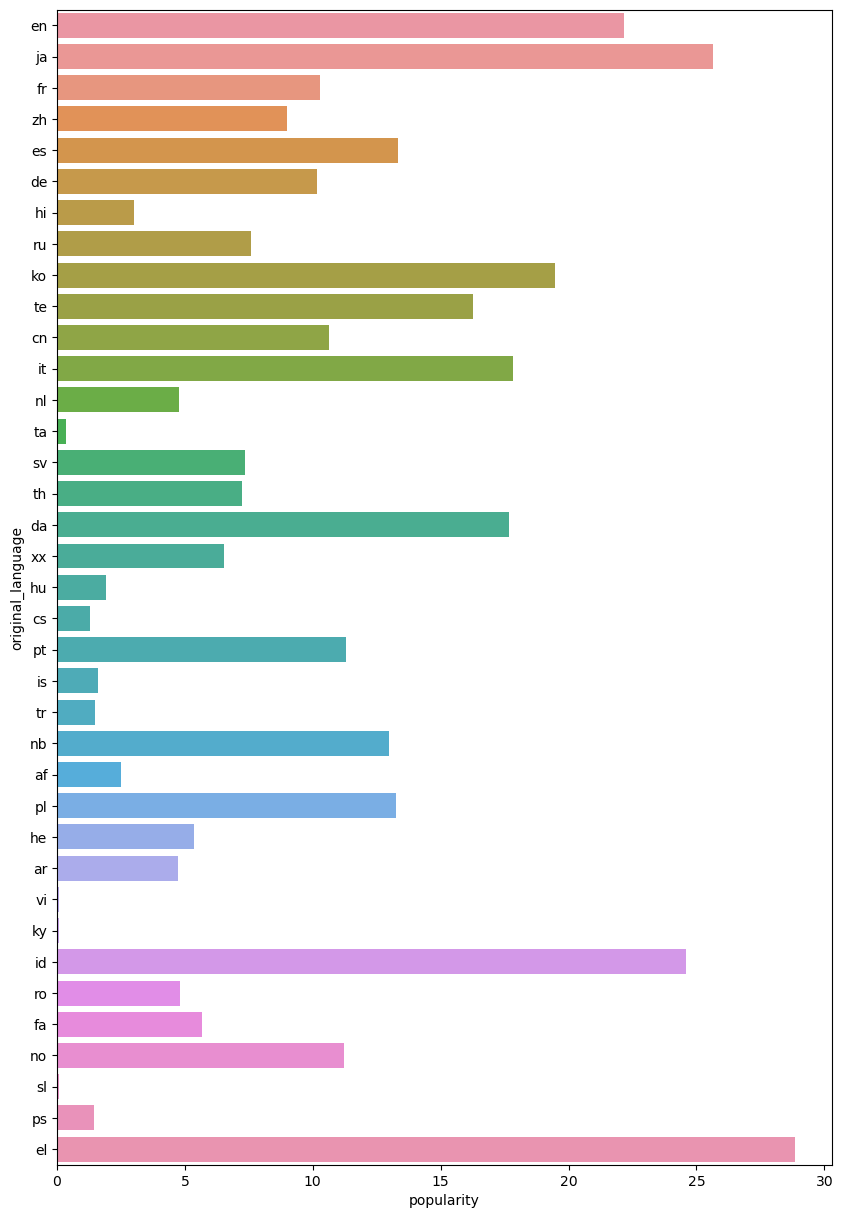

In [9]:
plt.figure(figsize=(10, 15))
sns.barplot(x="popularity", y="original_language", data=movies_df,
            label="Popularity", errorbar=None)
plt.show()

- Show popularity among languages used in the movies:
- X-label: popularity and Y-label: original_language
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows the popularity among original spoken languages for each movie."
  "This is important because it shows that movies with original language in greek ('el') are most popular. While, Japan (ja) and Indonesia (id) has higher uncertainty of popularity.  "
  "The key insight is Greek, Japanese, Indonesiaian is most popular spoken language original curated for among the movie data."


In [10]:
movies_df['release_date'].dt.year

0       2009.0
1       2007.0
2       2015.0
3       2012.0
4       2012.0
         ...  
4798    1992.0
4799    2011.0
4800    2013.0
4801    2012.0
4802    2005.0
Name: release_date, Length: 4803, dtype: float64

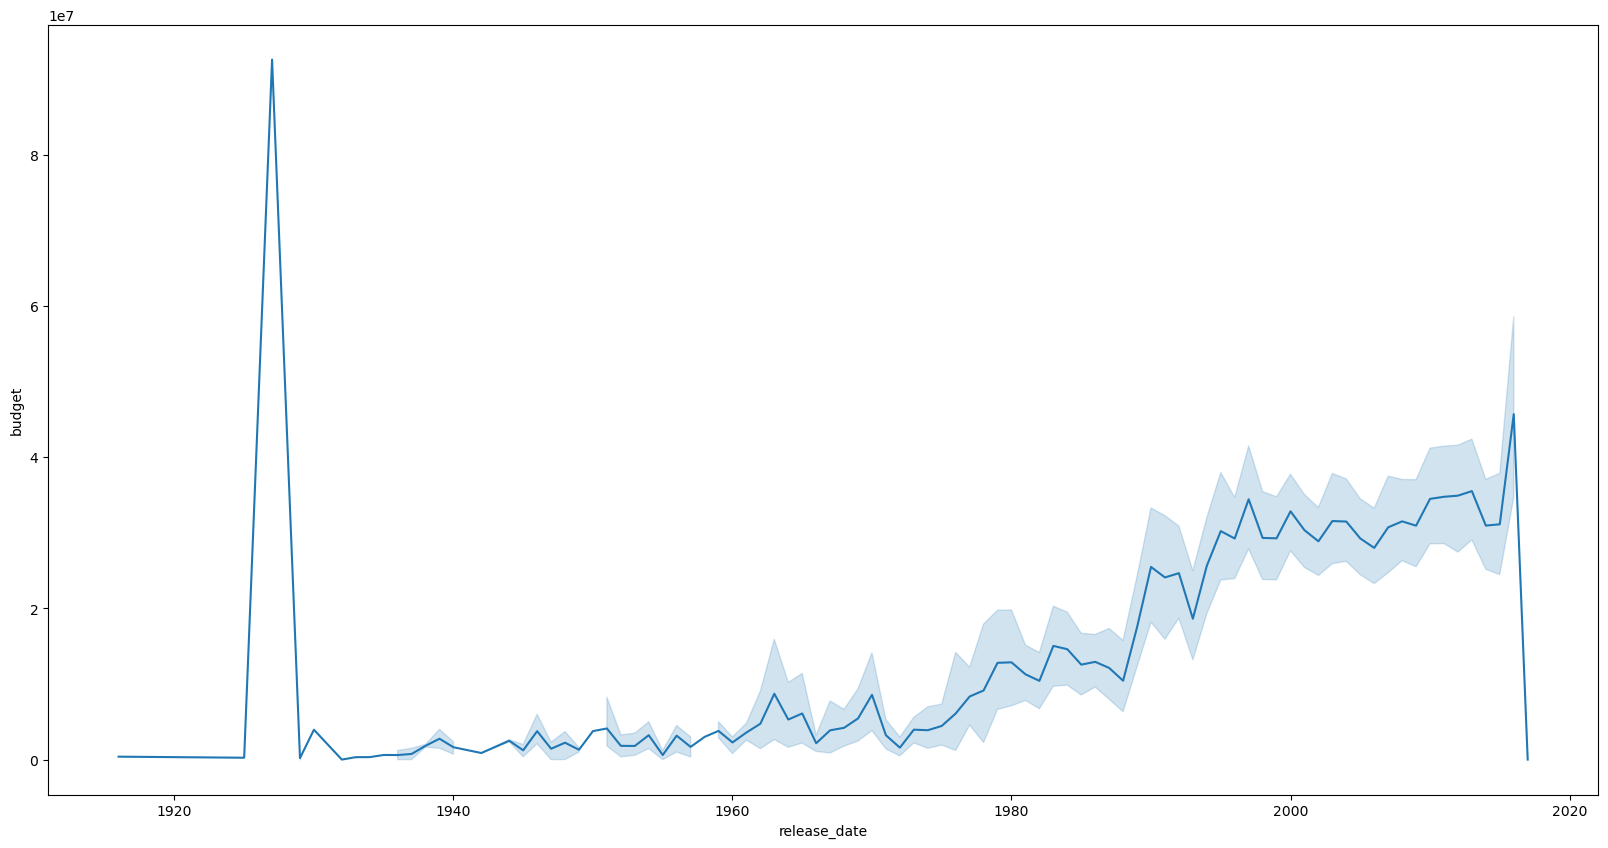

In [11]:
plt.figure(figsize=(20, 10))
sns.lineplot(x=movies_df['release_date'].dt.year, y="budget", data=movies_df)
plt.show()

- Show the trend among movie budgets each year:
- X-label: year and Y-label: budget (scientific notation)
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows trend/timeframe of investment in movies for each year."
  "This is important because it helps identify which years had the most investment budget wise."
  "The key insight is that movies released earlier between 1920 and 1940 had higher budgets, while movies released in 80s to 2000s saw a budget increase (not as high between 1920 and 1940)."


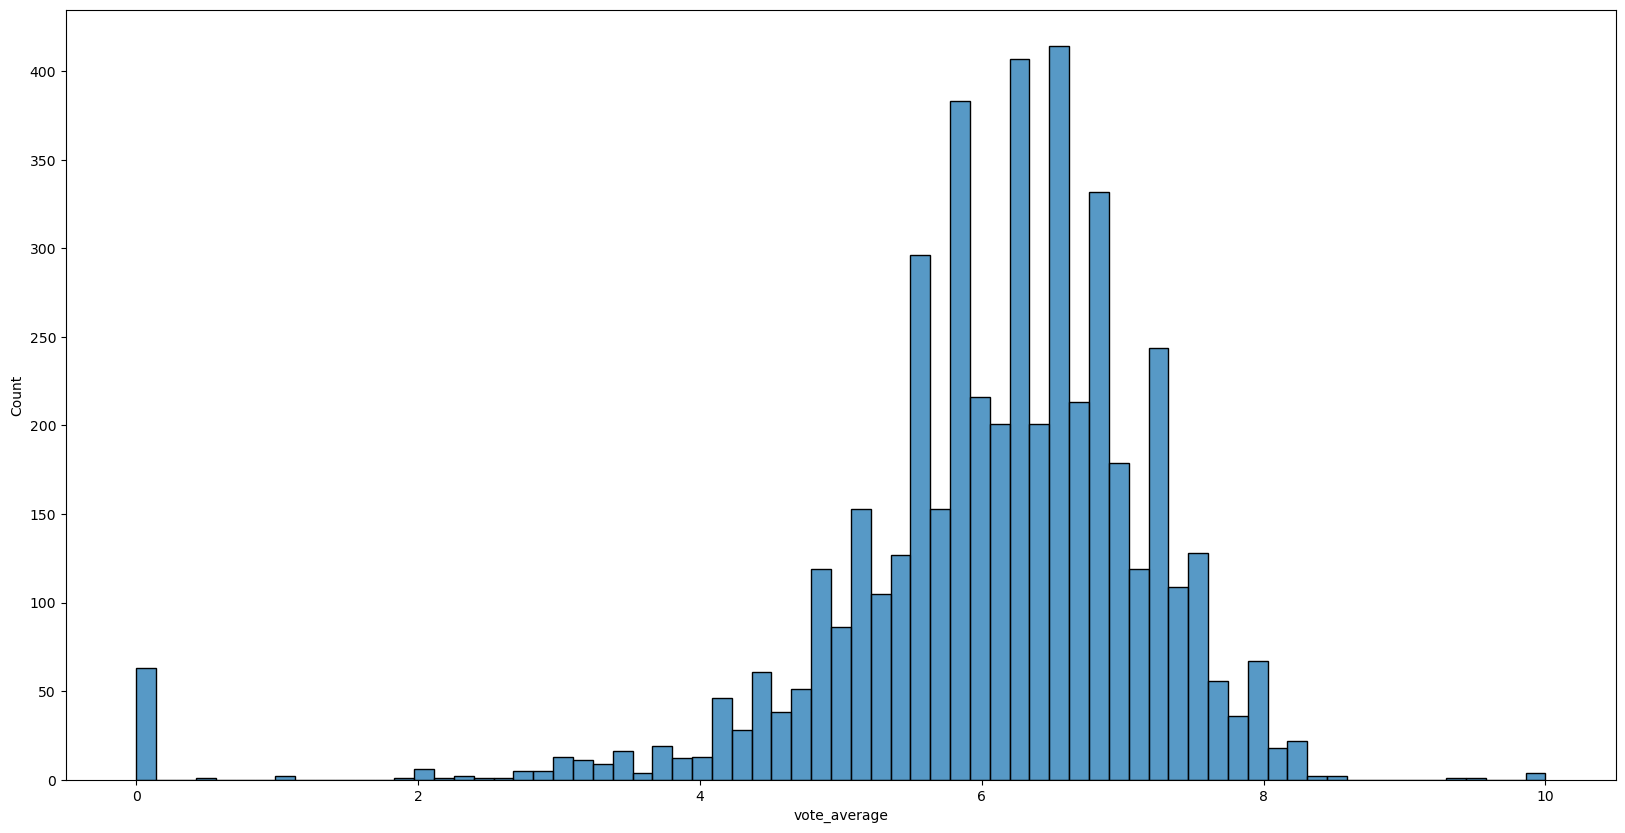

In [12]:
plt.figure(figsize=(20, 10))
sns.histplot(movies_df, x="vote_average")
plt.show()

- Show the distribution among movie ratings:
- X-label: vote_average and Y-label: count
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows distribution of the average review rating for each movie."
  "This is important because it helps identify the distribution, skewness, spread and peaks among the average review rating."
  "The key insight is there are higher peaks of average reviews between 5 and 7. There is a spread between average reviews below 4. The histogram is slightly left skewed (negatively skewed) mean < median < mode."

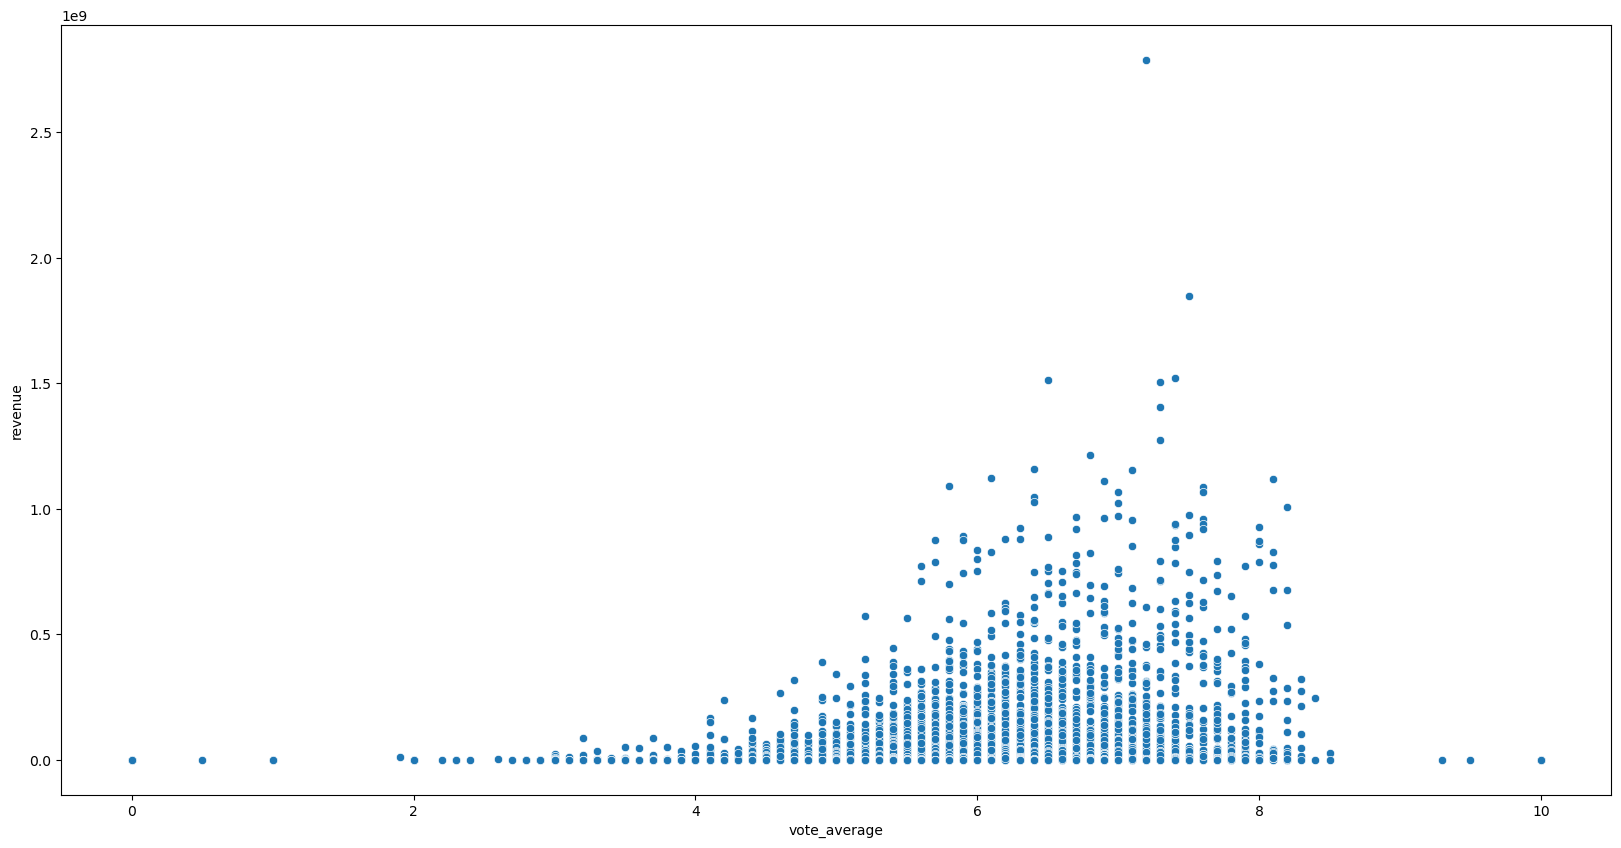

In [13]:
plt.figure(figsize=(20, 10))
sns.scatterplot(x=movies_df['vote_average'], y="revenue", data=movies_df)
plt.show()

- Relationship between average rating and revenue:
- X-label: vote_average and Y-label: revenue
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows relationship/correlation between the vote_average and revenue."
  "This is important because helps draw any points on how the vote_average effects the revenue."
  "The key insight is the clustering between average votes of 5 and 8. Slightly higher the revenue the better average votes on the movie."


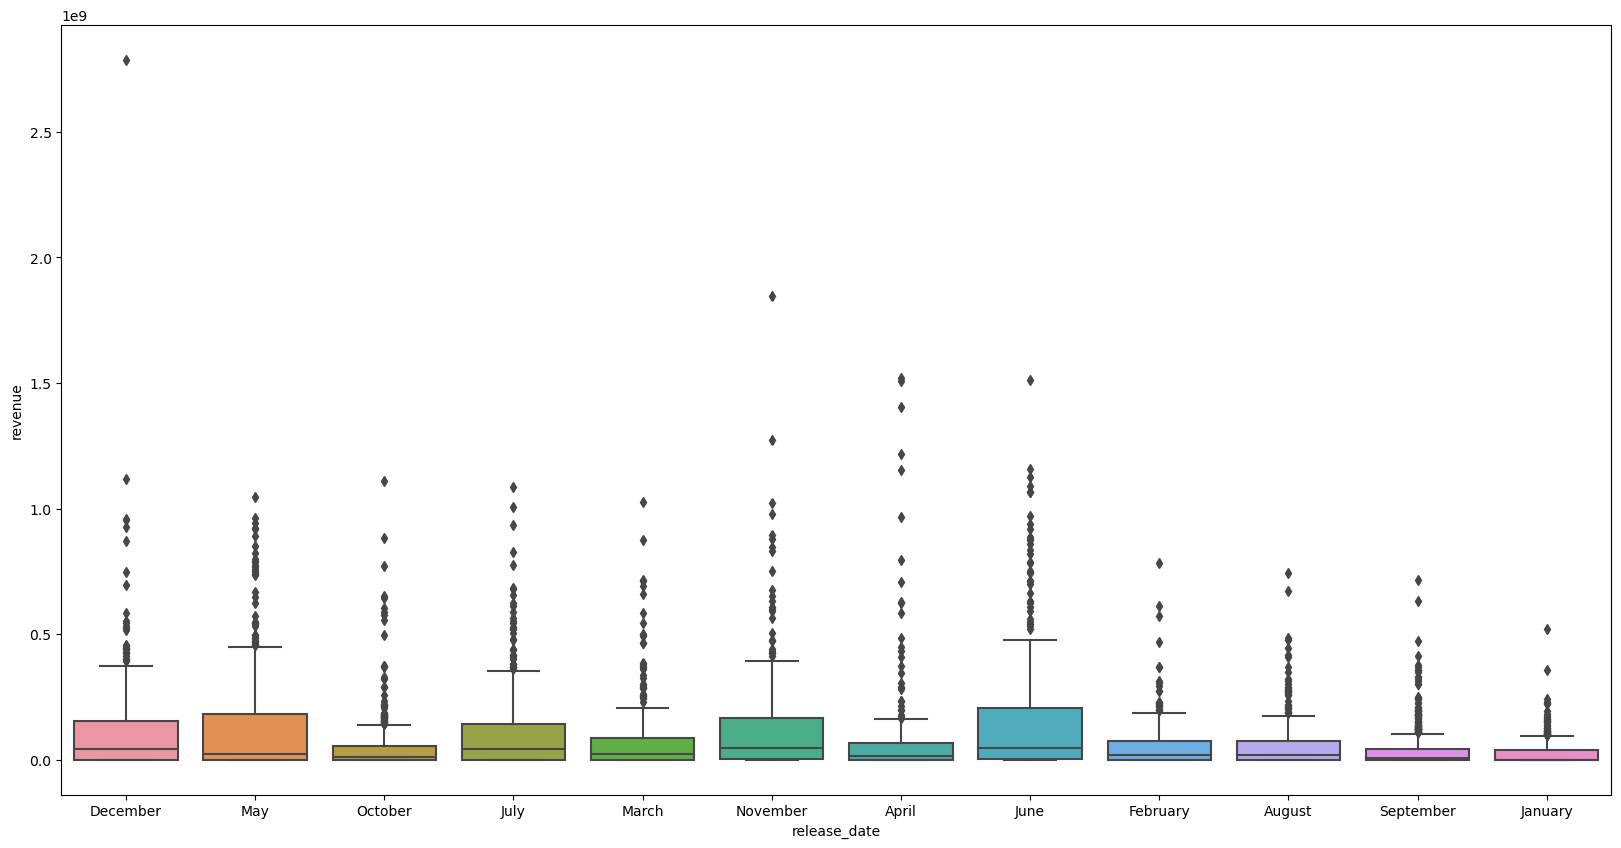

In [14]:
plt.figure(figsize=(20, 10))
sns.boxplot(movies_df, x=movies_df['release_date'].dt.month_name(), y="revenue")
plt.show()

- Show distribution of revenue among release months from movie data:
- X-label: months and Y-label: revenue
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows the distribution of revenue from release month."
  "This is important because identifies which release months generates the most or least in revenue."
  "The key insight is Summer and Holiday months generate the most in revenue."

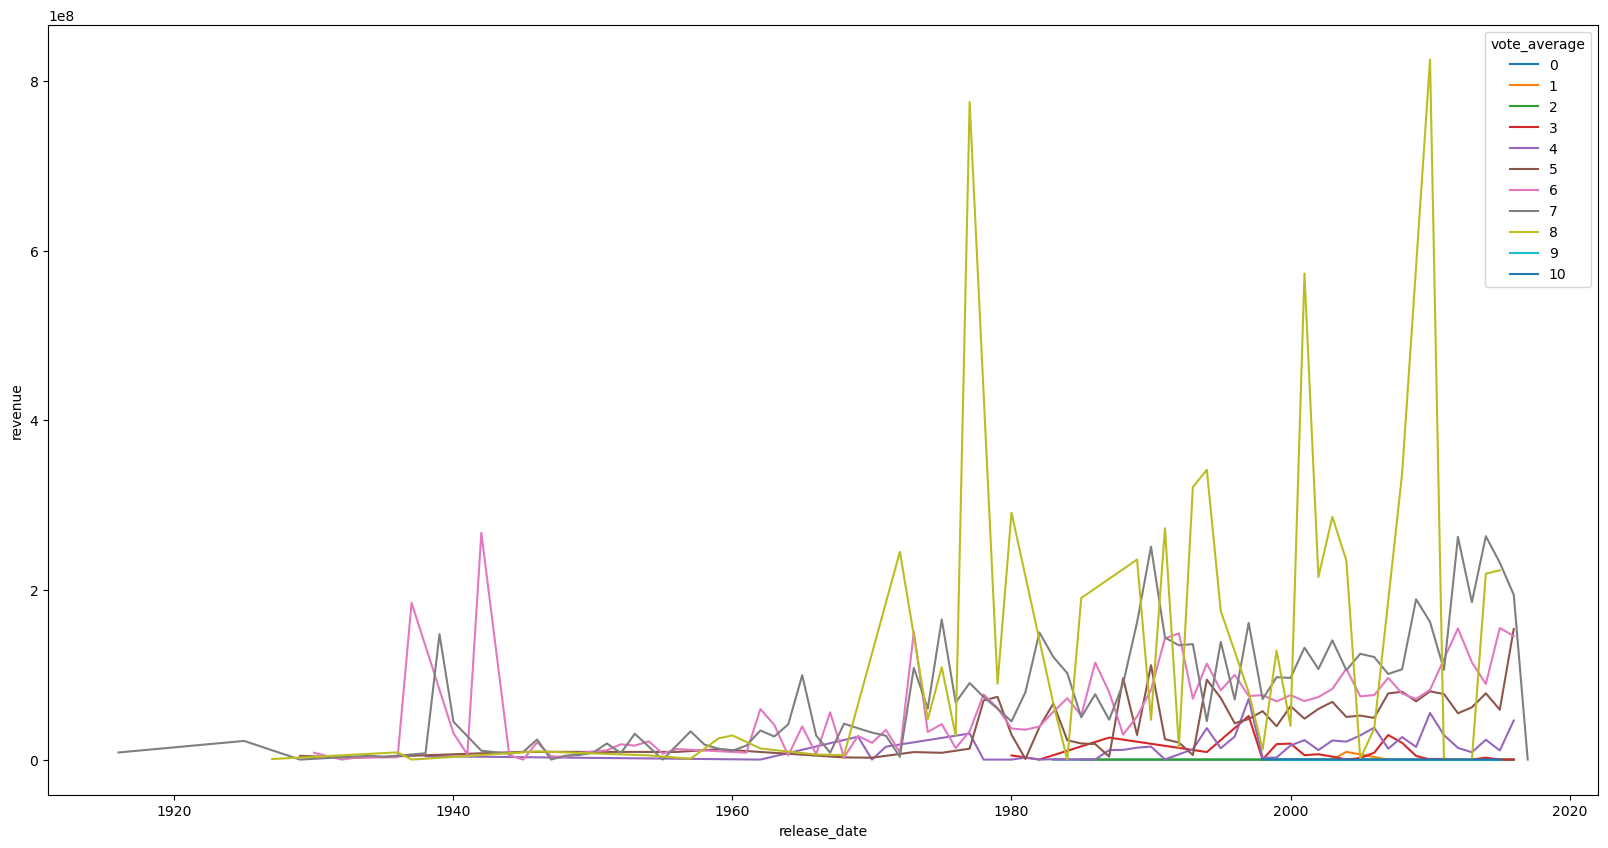

In [15]:
plt.figure(figsize=(20, 10))
sns.lineplot(data=movies_df, x=movies_df['release_date'].dt.year, y='revenue', hue=movies_df['vote_average'].astype(int),
            errorbar=None, palette='tab10')
plt.show()

- Show the trend every year the revenue generated based off the rating:
- X-label: release_date and Y-label: revenue
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows trend each year of the revenue filtered by the vote_average."
  "This is important because it helps identify  if the rating average impacts the revenue generated."
  "The key insight is the rating average between 7 and 8 generates the most in revenue. Slight realationship between revenue and rating."

<Figure size 2000x1000 with 0 Axes>

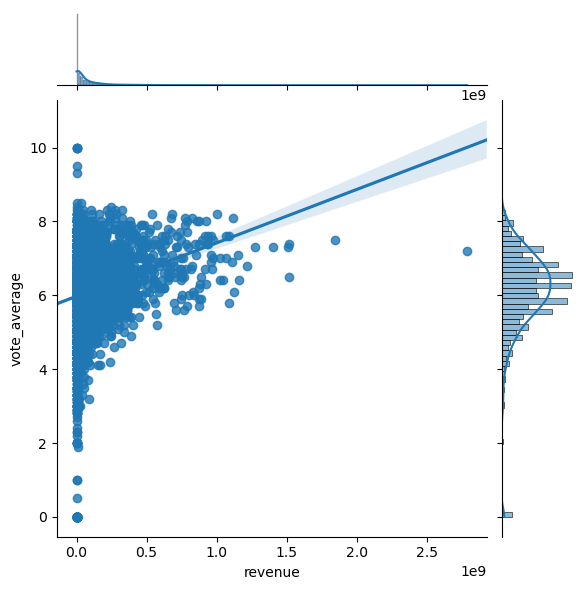

In [16]:
# jointplot:
plt.figure(figsize=(20, 10))
sns.jointplot(x="revenue", y="vote_average", data=movies_df,
                  kind="reg", truncate=False)
plt.show()

- How does rating influence the revenue generated?:
- X-label:revenue and Y-label:vote_average
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows the distribution of revenue based on vote_average."
  "This is important because it shows the connection between the rating and revenue generated."
  "The key insight is a rating between 6 - 8 generates the most in revenue."


<Figure size 2000x1000 with 0 Axes>

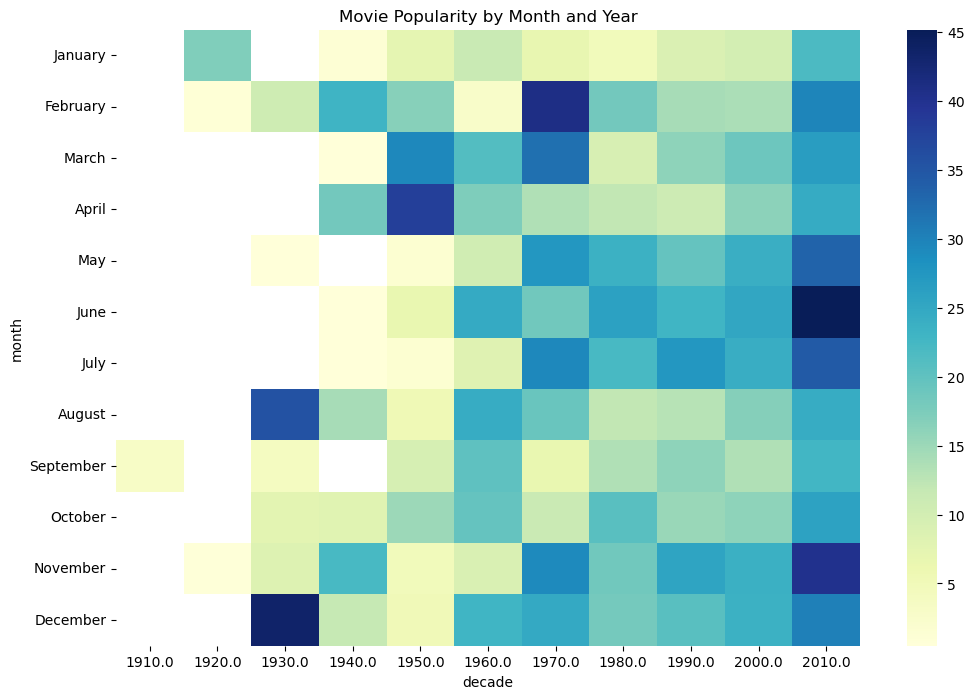

In [17]:
# heatmap:
plt.figure(figsize=(20, 10))
movies_df['year'] = movies_df['release_date'].dt.year
movies_df['month'] = movies_df['release_date'].dt.month_name()
movies_df['decade'] = (movies_df['release_date'].dt.year // 10) * 10

# Use pivot_table to handle multiple entries per month/year
movies_mapping = movies_df.pivot_table(
    index='month', 
    columns='decade', 
    values='popularity', 
    aggfunc='mean' # Use 'sum' or 'mean' to aggregate multiple movies
)

# reorder
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
movies_mapping = movies_mapping.reindex(month_order)

plt.figure(figsize=(12, 8))
sns.heatmap(movies_mapping, cmap="YlGnBu")
plt.title('Movie Popularity by Month and Year')
plt.show()

- Movie Popularity based off of release data:
- X-label:years and Y-label:months
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows Popularity scale of movies based off release data (month/year)."
  "This is important because identifies which month/year had highest popularity."
  "The key insight is Summer and Holiday months had the most movie popularity. 2010s had more popularity of movies. (advertising)."

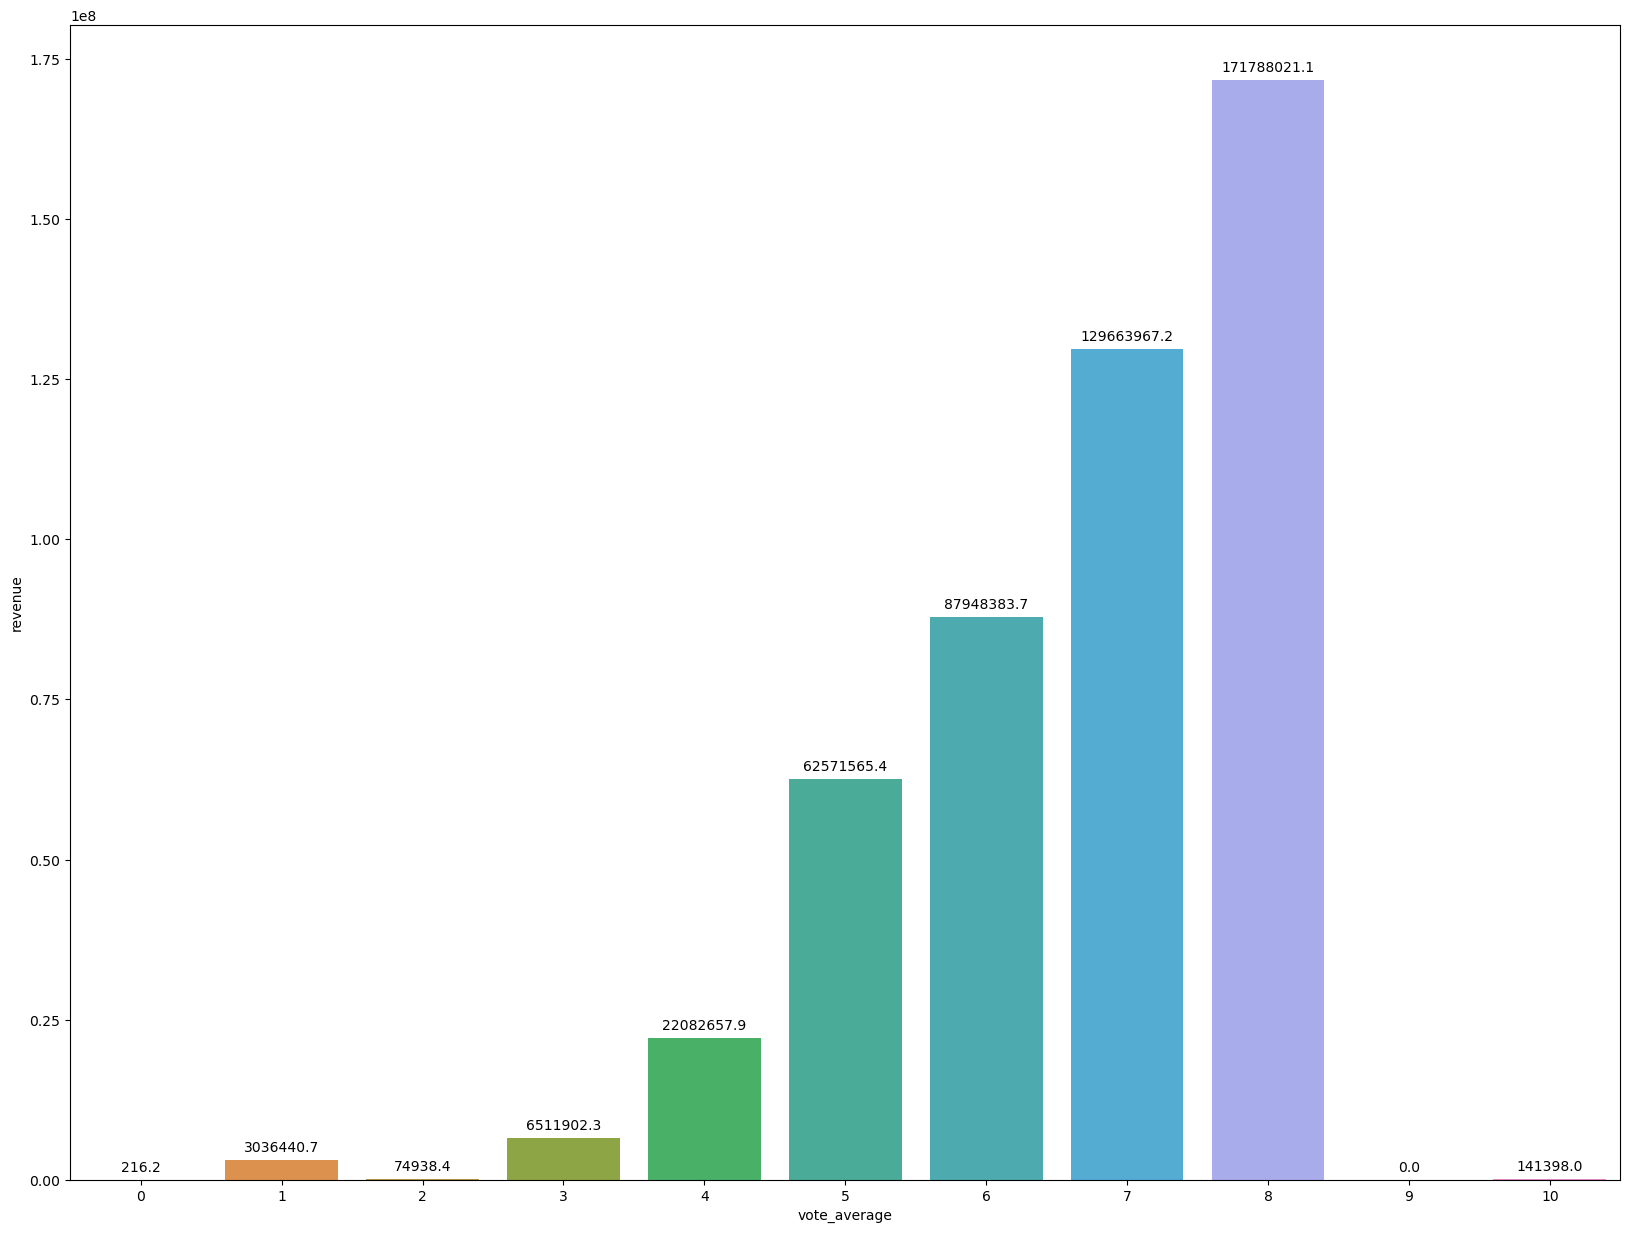

In [18]:
ax = plt.figure(figsize=(20, 15))
ax = sns.barplot(x=movies_df['vote_average'].astype(int), y="revenue", data=movies_df, errorbar=None)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

- Scale of revenue generated based off of the rating:
- X-label: vote_average and Y-label: revenue
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows categorical summary of revenue based on vote_average."
  "This is important because displays which rating category generates the most/least in revenue."
  "The key insight is ratings between 5 and 8 generate the most in revenue, while ratings below 4 and higher than 8 generate the least."


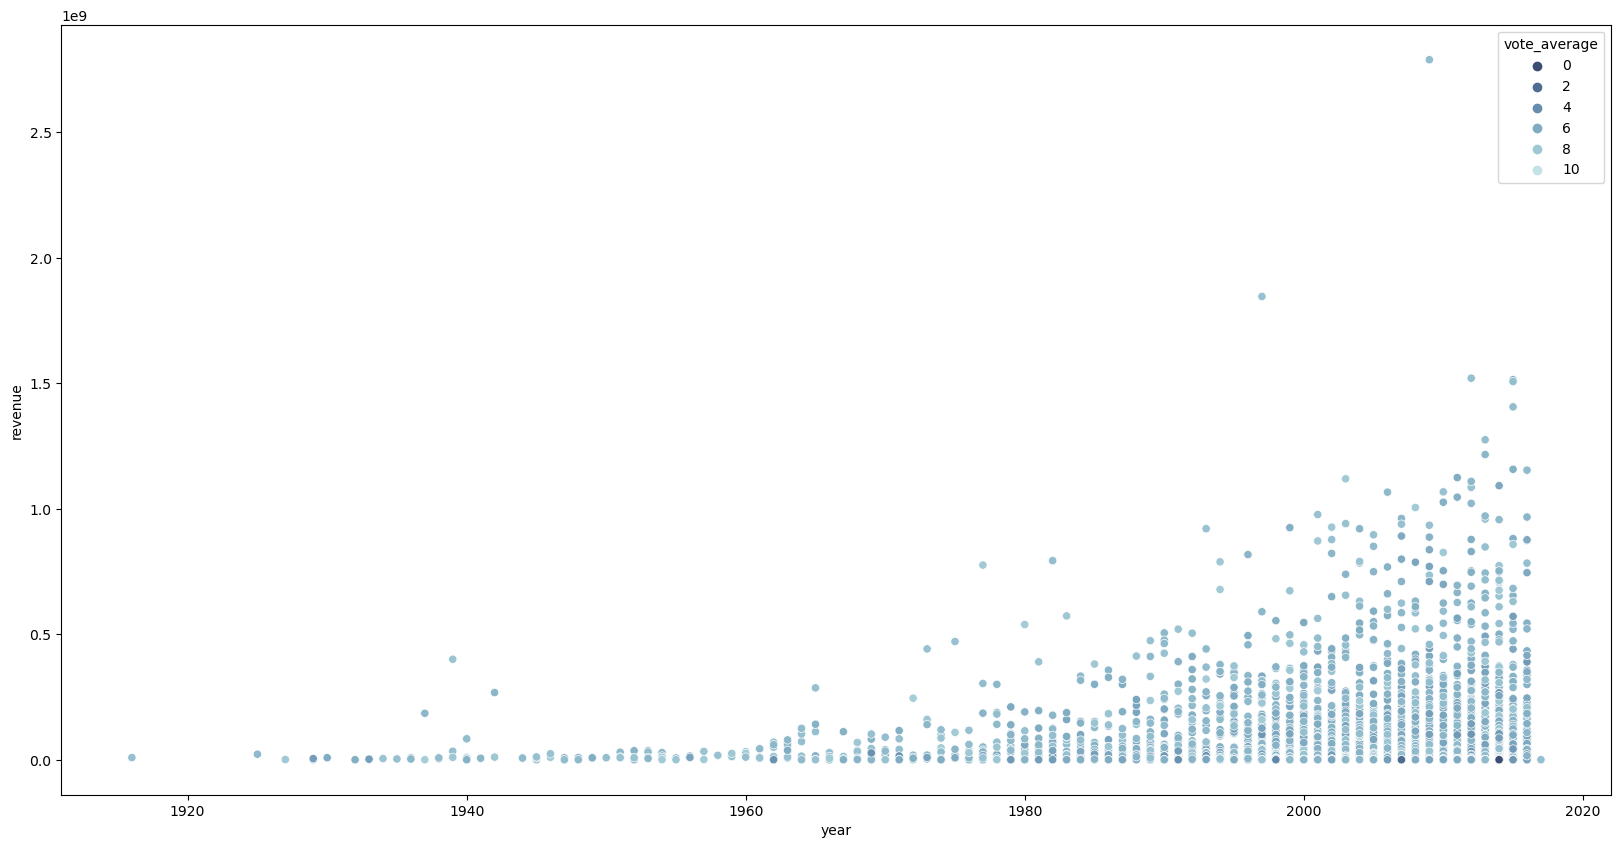

In [38]:
plt.figure(figsize=(20, 10))
sns.scatterplot(x="year", y="revenue",
                hue=movies_df["vote_average"],
                palette="ch:r=-.2,d=.3_r",
                data=movies_df)
plt.show()

- Realationship between rating and revenue:
- X-label: year and Y-label: revenue
- Appropriate scale
- Consistent color scheme
- A short interpretation below the plot:
  "This visualization shows realationship/correlation of rating and revenue throughout the year."
  "This is important because it helps visualize important realationship of rating and revenue by year."
  "The key insight is rating of 6 to 8 generates the most in revenue, while rating below 4 and between 9 to 10 generates the least."
